In [3]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

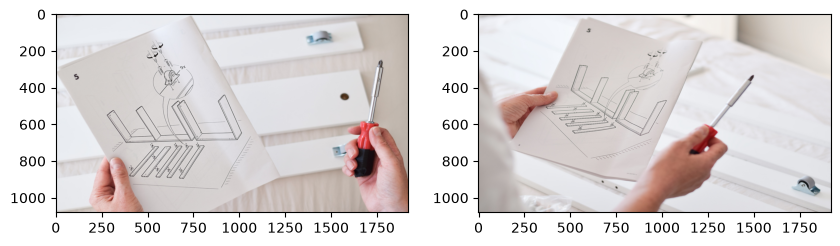

In [4]:
image_1 = cv2.imread(r"C:\Users\Victor\Documents\nexvisual\1.jpeg")
image_2 = cv2.imread(r"C:\Users\Victor\Documents\nexvisual\2.jpeg")


fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10,8))
axes[0].imshow(cv2.cvtColor(image_1, cv2.COLOR_BGR2RGB))
axes[1].imshow(cv2.cvtColor(image_2, cv2.COLOR_BGR2RGB))

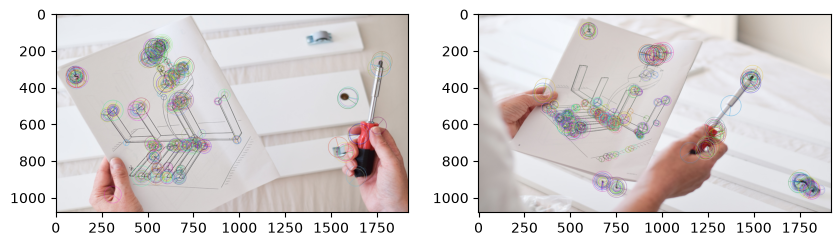

In [7]:
# Criando o detector com ORB
orb = cv2.ORB_create()

keypoints_1, descriptors_1 = orb.detectAndCompute(image_1, None)
keypoints_2, descriptors_2 = orb.detectAndCompute(image_2, None)

# Visualizando os Keypoints
image_kp_1 = cv2.drawKeypoints(image_1, keypoints_1, None, flags= cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)
image_kp_2 = cv2.drawKeypoints(image_2, keypoints_2, None, flags= cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10,8))
axes[0].imshow(cv2.cvtColor(image_kp_1, cv2.COLOR_BGR2RGB))
axes[1].imshow(cv2.cvtColor(image_kp_2, cv2.COLOR_BGR2RGB))
plt.show()


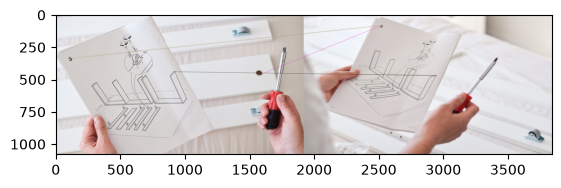

In [ ]:
# Criando o matcher de força bruta
brute_force = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)

# Realizando o matching entre os descritores
matches = brute_force.match(descriptors_1, descriptors_2)

# Ordenando os matches com menor distância
matches = sorted(matches, key= lambda x:x.distance)

# Desenhar os 5 matches mais próximos
num = 5 
image_matches = cv2.drawMatches(cv2.cvtColor(image_1, cv2.COLOR_BGR2RGB), keypoints_1, cv2.cvtColor(image_2, cv2.COLOR_BGR2RGB), keypoints_2, matches[:num], None, flags= cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)

plt.imshow(image_matches)